In [1]:
import xarray as xr

cfa_file = "/gws/ssde/j25b/eds_ai/frame-fm/data/inputs/chess-met/aggregations/chess-met_dtr_gb_1km_daily_19610101-20191231.nca"
ds = xr.open_dataset(cfa_file, engine='CFA')

In [3]:
ds

<xarray.Dataset> Size: 60GB
Dimensions:    (x: 656, y: 1057, time: 21549, bnds: 2)
Coordinates:
  * x          (x) float64 5kB 500.0 1.5e+03 2.5e+03 ... 6.545e+05 6.555e+05
  * y          (y) float64 8kB 500.0 1.5e+03 2.5e+03 ... 1.056e+06 1.056e+06
  * time       (time) datetime64[ns] 172kB 1961-01-01 1961-01-02 ... 2019-12-31
Dimensions without coordinates: bnds
Data variables:
    lat        (y, x) float64 6MB ...
    lon        (y, x) float64 6MB ...
    time_bnds  (time, bnds) datetime64[ns] 345kB ...
    x_bnds     (x, bnds) float64 10kB ...
    y_bnds     (y, bnds) float64 17kB ...
    crsOSGB    int32 4B ...
    dtr        (time, y, x) float32 60GB ...
Attributes: (12/35)
    Conventions:                   CF-1.12, ACDD
    title:                         Climate hydrology and ecology research sup...
    source:                        This data set has been generated from a nu...
    cdm_data_type:                 Grid
    spatial_resolution_distance:   1000.0
    spatial_resolution_unit:       urn:ogc:def:uom:EPSG::9001
    ...                            ...
    summary:                       Gridded daily meteorological variables ove...
    history:                       See individual datasets for more information.
    date_created:                  See individual datasets for more information.
    creator_name:                  See individual datasets for more information.
    contributor_name:              Robinson, E. L., Blyth, E. M., Clark, D. B...
    licence:                       See individual datasets for more information.

In [4]:
air_temp = ds.dtr

In [5]:
air_temp.size

14941904208

In [11]:
#subset = air_temp.sel(time=slice("1966-01-10", "1966-03-01"))
subset = air_temp.isel(time=slice(0, 1))
subset.size

693392

In [20]:
s = subset.squeeze()

In [22]:
arr = s.to_numpy().reshape([1057, 656])
arr.shape

(1057, 656)

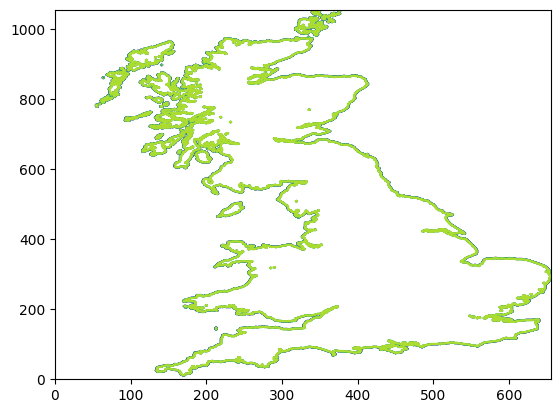

In [24]:
import matplotlib.pyplot as plt
plt.contour(arr)